# OLS-Modelltraining

In diesem Notebook ist die Fokus auf eine hypothesengeleitete Modellierung mit Ordinary Least Squares (OLS), um den Einfluss spezifischer Merkmale zu untersuchen.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import scipy.stats as stats
import statsmodels.api as sm 

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

## Hypothese (Gesamtsignifikanz des Modells):

- H0: 
    - Die Gesamtheit der ausgewählten Prädiktoren (is_verified, account_category, follower_count etc.) hat keinen linearen Einfluss auf likes_log.
- H1: 
    - Mindestens einer der ausgewählten Prädiktoren hat einen signifikanten linearen Einfluss auf likes_log. 

In [77]:
df_gefiltert = pd.read_pickle('verarbeitete_daten.pkl')

### Metadaten-Features für das OLS-Modell

OLS-Modell Metadaten Auswahl basiert auf der vorherigen explorativen Datenanalyse (EDA)

In [78]:
# FEATURES basierend auf die Ergebnisse der Explorativen Datenanalyse (EDA) 
feature_columns_for_ols = [
    
    # numerische Features
    
    'follower_count',       # Stark signifikant (+)
    'comment_count',        # Grenzwertig signifikant (+)
    'hashtag_count',        # Stark signifikant (-)
    # 'caption_length',     # Nicht signifikant 
    # 'mention_count',      # Nicht signifikant 
    # 'media_count_in_post',# Nicht signifikant 
    # 'hour_of_day',        # Nicht signifikant 
    # 'day_of_week',        # Nicht signifikant
    # 'month'               # Nicht signifikant    
    
    # kategoriale Features
    
    'is_verified',          # Stark signifikant (+)
    'is_professional_account', # Stark signifikant (+)
    'account_category',     # Viele Kategorien signifikant (+/-)
    'is_business_account',  # Grenzwertig signifikant (-)
    # 'post_type',          # Nicht signifikant
]

existing_ols_col = [col for col in feature_columns_for_ols if col in df_gefiltert.columns]
X_ols = df_gefiltert[existing_ols_col].copy()
y_ols = df_gefiltert['likes_log'].copy()
print(f"Anzahl Zeilen vor NaN-Behandlung in X_ols: {len(X_ols)}")

# Fehlende Werte in 'account_category' mit 'Unbekannt' füllen
if 'account_category' in X_ols.columns:
    X_ols['account_category'] = X_ols['account_category'].fillna('Unbekannt')
else: 
    X_ols['account_category'] = 'Unbekannt'

print(f"Anzahl Zeilen nach NaN-Behandlung in X_ols: {len(X_ols)}")
print("\nAusgewählte und bereinigte Features für OLS-Modell (X_ols):")
X_ols.info()

# Identifiziere numerische und kategoriale Spalten 
numerical_cols_ols = X_ols.select_dtypes(include=np.number).columns.tolist()
categorical_cols_ols = X_ols.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

categorical_cols_ols = sorted(list(set(categorical_cols_ols)))
numerical_cols_ols = sorted(list(set(numerical_cols_ols)))


print(f"\nFinale numerische Features für Preprocessing (OLS): {numerical_cols_ols}")
print(f"Finale kategoriale Features für Preprocessing (OLS): {categorical_cols_ols}")

# Preprocessing Pipelines
numerical_pipeline_ols = Pipeline([
    ('scaler', StandardScaler())
])

# Kategoriale Features werden mit OneHotEncoder verarbeitet 
categorical_pipeline_ols = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')),
    ('scaler', StandardScaler())
])


preprocessor_ols = ColumnTransformer([
    ('numerical', numerical_pipeline_ols, numerical_cols_ols),
    ('categorical', categorical_pipeline_ols, categorical_cols_ols)
], remainder='drop')


# Aufteilung in Trainings- und Testsets
X_train_ols_split, X_test_ols_split, y_train_ols, y_test_ols = train_test_split(X_ols, y_ols, test_size=0.4, random_state=42)

print(f"\nGröße Trainingsdaten X (OLS): {X_train_ols_split.shape}")
print(f"Größe Testdaten X (OLS): {X_test_ols_split.shape}")

if X_train_ols_split.empty:
    raise ValueError("X_train_ols_split ist leer nach dem Splitten. Überprüfe die Daten und Feature-Auswahl.")

Anzahl Zeilen vor NaN-Behandlung in X_ols: 1968
Anzahl Zeilen nach NaN-Behandlung in X_ols: 1968

Ausgewählte und bereinigte Features für OLS-Modell (X_ols):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   follower_count           1968 non-null   int64 
 1   comment_count            1968 non-null   int64 
 2   hashtag_count            1968 non-null   int64 
 3   is_verified              1968 non-null   bool  
 4   is_professional_account  1968 non-null   bool  
 5   account_category         1968 non-null   object
 6   is_business_account      1968 non-null   bool  
dtypes: bool(3), int64(3), object(1)
memory usage: 67.4+ KB

Finale numerische Features für Preprocessing (OLS): ['comment_count', 'follower_count', 'hashtag_count']
Finale kategoriale Features für Preprocessing (OLS): ['account_category', 'is_business_accoun

### Training eines auf der Hypothese basierenden Modells (Lineare Regression mit statsmodels) 

In [79]:
print("Starte Daten-Preprocessing für das fokussierte OLS-Modell...")
ols_model = None # Initialisiere, um Fehler im Except-Block zu vermeiden
X_test_ols_processed_df = None # Initialisiere

try:
    X_train_processed_ols_np = preprocessor_ols.fit_transform(X_train_ols_split)
    X_test_processed_ols_np = preprocessor_ols.transform(X_test_ols_split)
    print(f"Preprocessing abgeschlossen. Shape von X_train_processed_ols_np: {X_train_processed_ols_np.shape}")

    # Feature-Namen nach dem Preprocessing holen
    transformed_feature_names_ols = []
    if numerical_cols_ols: # Nur wenn es numerische Spalten gibt
        transformed_feature_names_ols.extend(numerical_cols_ols)
    if categorical_cols_ols: # Nur wenn es kategoriale Spalten gibt
        ohe_transformer = preprocessor_ols.named_transformers_['categorical'].named_steps['onehot']
        if hasattr(ohe_transformer, 'get_feature_names_out'):
            transformed_feature_names_ols.extend(ohe_transformer.get_feature_names_out(categorical_cols_ols))
        else: 
            print("WARNUNG: get_feature_names_out nicht verfügbar für OHE. Feature-Namen in Summary könnten unvollständig sein.")


    # DataFrame erstellen für statsmodels (mit korrekten Namen, falls möglich)
    num_cols_after_transform = X_train_processed_ols_np.shape[1]
    if transformed_feature_names_ols and num_cols_after_transform == len(transformed_feature_names_ols):
        current_cols_for_df = transformed_feature_names_ols
    else:
        print(f"WARNUNG: Anzahl extrahierter Namen ({len(transformed_feature_names_ols)}) passt nicht zu Spalten ({num_cols_after_transform}). Verwende generische Namen.")
        current_cols_for_df = [f"feature_{i}" for i in range(num_cols_after_transform)]
        transformed_feature_names_ols = current_cols_for_df # Wichtig für die Summary-Funktion

    X_train_processed_ols_df = pd.DataFrame(X_train_processed_ols_np, columns=current_cols_for_df, index=X_train_ols_split.index)
    X_test_processed_ols_df = pd.DataFrame(X_test_processed_ols_np, columns=current_cols_for_df, index=X_test_ols_split.index)

    # Füge eine Konstante für den Intercept hinzu
    X_train_sm = sm.add_constant(X_train_processed_ols_df.reset_index(drop=True), has_constant='add')
    X_test_sm = sm.add_constant(X_test_processed_ols_df.reset_index(drop=True), has_constant='add')

    print("\nStarte OLS-Modelltraining (fokussiert)...")
    ols_model_obj = sm.OLS(y_train_ols.reset_index(drop=True), X_train_sm)
    ols_model = ols_model_obj.fit() # Das ist dein 'results' Objekt
    print("OLS-Modelltraining (fokussiert) abgeschlossen.")

except Exception as e:
    print(f"Fehler während des Preprocessings oder OLS-Modelltrainings (fokussiert): {e}")

Starte Daten-Preprocessing für das fokussierte OLS-Modell...
Preprocessing abgeschlossen. Shape von X_train_processed_ols_np: (1180, 31)

Starte OLS-Modelltraining (fokussiert)...
OLS-Modelltraining (fokussiert) abgeschlossen.


### Evaluierung des hypothesenbasierten Modells (OLS-Regression) 

In [80]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:              likes_log   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     74.09
Date:                Tue, 27 May 2025   Prob (F-statistic):          1.24e-248
Time:                        20:57:03   Log-Likelihood:                -2483.2
No. Observations:                1180   AIC:                             5030.
Df Residuals:                    1148   BIC:                             5193.
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

### Interpretation der OLS-Ergebnisse:

1. Gesamtsignifikanz des Modells:

- F-Statistik: 74.09 Dies ist ein sehr hoher Wert, der darauf hindeutet, dass das Modell als Ganzes statistisch signifikant ist. H0 wird eindeutig verworfen, da der p-Wert (1.24e-248) weit unter 0.05 liegt. Die 31 ausgewählten Prädiktoren (Df Model) leisten gemeinsam einen signifikanten Beitrag zur Erklärung der Varianz in likes_log.(siehe auch unten die F-Verteilung und t-Verteilung Diagramme).

2. Modellgüte:
- R-squared: 0.667: Ca. 66.7% der Varianz in der log-transformierten Like-Anzahl (likes_log) können durch die im Modell enthaltenen Features erklärt werden.

- Adj. R-squared: 0.658: Das adjustierte R-Quadrat, das die Anzahl der Prädiktoren berücksichtigt, ist mit 0.658 nur geringfügig niedriger. Dies ist ein positives Zeichen und deutet darauf hin, dass die Reduktion der Feature-Anzahl nicht zu einem wesentlichen Verlust an Erklärungskraft auf den Trainingsdaten geführt hat und das Modell potenziell robuster ist.

3. Degrees of Freedom (Df):
- Df Model: 31: Das Modell enthält 31 Prädiktoren, die zur Erklärung der Varianz in likes_log beitragen.

- Df Residuals: 1148: Freiheitsgrade der Residuen. Das Verhältnis von Beobachtungen zu Prädiktoren (1180/31≈38) ist gut und deutet auf eine stabilere Schätzung hin.

#### Interpretation ausgewählter Koeffizienten

- Intercept/Konstante: Der Grundwert für likes_log, wenn alle anderen (skalierten numerischen und Dummy-) Features Null wären. Hoch signifikant.

##### Signifikante positive Einflussfaktoren auf likes_log:

- follower_count: coef: 0.4502, P>|t|: 0.000. (H0 verworfen). Bestätigt den starken positiven Einfluss.

- is_verified_True: coef: 0.5931, P>|t|: 0.000. (H0 verworfen). Verifizierte Accounts erhalten signifikant mehr Likes (log).

- is_professional_account_True: coef: 0.3868, P>|t|: 0.000. (H0 verworfen). Professionelle Accounts performen signifikant besser.

- account_category_Athlete: coef: 1.0343, P>|t|: 0.000. (H0 verworfen). Sehr starker positiver Einfluss im Vergleich zur Referenzkategorie.


##### Signifikante negative Einflussfaktoren auf likes_log:

- account_category_Musician: coef: -1.1102, P>|t|: 0.000. Der stärkste negative Einfluss unter den Kategorien.

- hashtag_count: coef: -0.7954, P>|t|: 0.000. (H0 verworfen). Der starke negative Einfluss bleibt bestehen.

- account_category_Entrepreneur: coef: -0.8023, P>|t|: 0.000. Der negative Einfluss bleibt stark und signifikant.

##### Diagnostik der Modelannahmen:

- Residuenverteilung: Prob(Omnibus): 0.000, Skew: -0.687, Kurtosis: 6.652. Die Residuen sind nicht normalverteilt, was ein wichtiger Kritikpunkt an der Verlässlichkeit der p-Werte für die Inferenz ist.

- Autokorrelation: Durbin-Watson: 2.022. Gut, spricht gegen Autokorrelation.

- Multikollinearität: Cond. No.: 5.98. Dies ist ein guter Wert! Die Schätzung der Koeffizienten sind stabil und ihre Interpretation zuverlässig (unter der Annahme, dass andere OLS-Annahmen erfüllt wären).

##### Fazit:

Das OLS-Modell zeigt eine starke Gesamtsignifikanz und erklärt einen großen Teil der Varianz in likes_log. Die signifikanten Prädiktoren liefern wertvolle Einblicke in die Faktoren, die die Like-Anzahl beeinflussen.
Bestätigte Haupteinflüsse: follower_count, is_verified, is_professional_account und account_category bleiben sehr wichtige Prädiktoren. Der negative Einfluss von hashtag_count ist ebenfalls robust.

Die Nicht-Normalverteilung der Residuen bleibt die größte Herausforderung für die statistische Inferenz (Gültigkeit der p-Werte und Konfidenzintervalle). Ein Random Forest ist der logische nächste Schritt, um die Limitationen des OLS-Modells zu überwinden, insbesondere die Nicht-Normalverteilung der Residuen und die inhärente Unfähigkeit, komplexe nicht-lineare Beziehungen und Interaktionen ohne manuelle Spezifikation zu modellieren. Die Erkenntnisse aus dem OLS sind dabei wertvoller Input für die Feature-Auswahl und das Verständnis des Random Forest Modells.



### Diagramme des OLS-Modells

#### F-Verteilungs-Diagramm

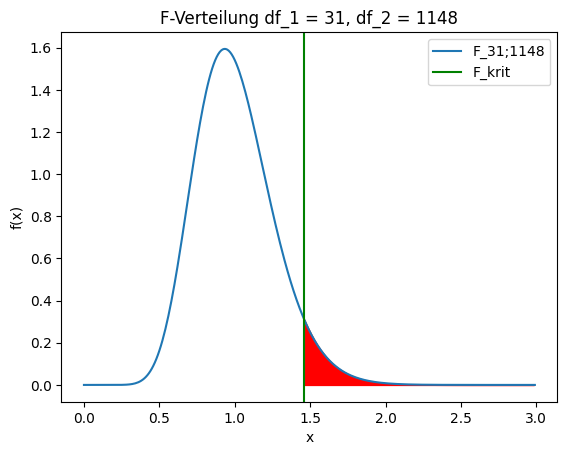

In [81]:
alpha = 0.05

# Freiheitsgrade
df_1 = ols_model.df_model  # Anzahl der Regressoren
df_2 = ols_model.df_resid  # Freiheitsgrade der Residuen

# Kritischer F-Wert für das Modell
F_krit = stats.f.ppf(1 - alpha, df_1, df_2)

b1, b2 = 0, 3
x_v = np.arange(b1, b2, 0.01)
plt.plot(x_v, stats.f.pdf(x_v, df_1, df_2), label=f'F_{df_1:.0f};{df_2:.0f}')
fill_l = np.arange(F_krit, b2, (b2-F_krit)/100)
plt.fill_between(fill_l, stats.f.pdf(fill_l, df_1, df_2), color='red')
plt.axvline(F_krit, color='green', label='F_krit')
plt.legend()
plt.title(f'F-Verteilung df_1 = {df_1:.0f}, df_2 = {df_2:.0f}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

##### Interpretation des F-Verteilungs-Diagramms

Der F-Wert des Modells beträgt 74.09 (aus dem OLS-Summary).
Dieser Wert liegt weit im roten Bereich (deutlich rechts vom kritischen Wert)
Daher wird H₀ mit sehr hoher Sicherheit abgelehnt. Die Wahrscheinlichkeit, einen so hohen F-Wert zufällig zu beobachten, wenn tatsächlich kein Zusammenhang besteht, ist extrem gering (p ≈ 1.24e-248).

#### t-Verteilungs-Diagramm

Ablehnungsbereich für H0: t < -1.962 oder t > 1.962


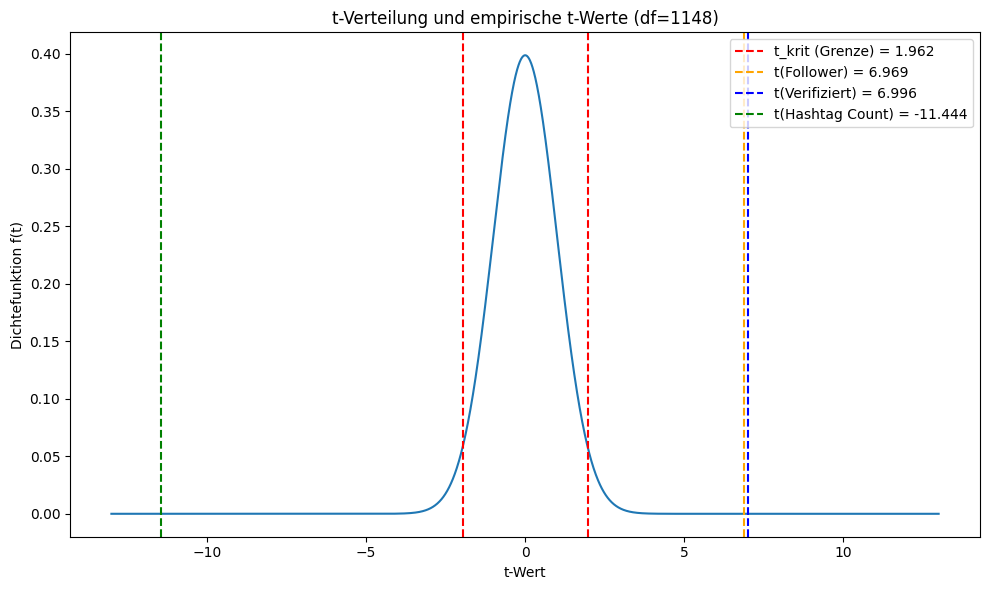

In [86]:
alpha = 0.05 # Signifikanzniveau
feature_name_follower = 'follower_count' 
feature_name_verified = 'is_verified_True' 
feature_name_professional = 'is_professional_account_True' 
feature_name_hashtag = 'hashtag_count' 

t_value_follower = ols_model.tvalues.get(feature_name_follower, np.nan) 
t_value_verified = ols_model.tvalues.get(feature_name_verified, np.nan)
t_value_third_hashtag = ols_model.tvalues.get(feature_name_hashtag, np.nan)



x_t = np.arange(-13, 13, 0.01) 
plt.figure(figsize=(10, 6))
plt.plot(x_t, stats.t.pdf(x_t, df=ols_model.df_resid))

# Kritische Werte für zweiseitigen Test
c_lower, c_upper = stats.t.interval(1 - alpha, df=ols_model.df_resid)
print(f'Ablehnungsbereich für H0: t < {c_lower:.3f} oder t > {c_upper:.3f}')

plt.axvline(c_lower, linestyle='--', color='red')
plt.axvline(c_upper, linestyle='--', color='red', label=f't_krit (Grenze) = {c_upper:.3f}')

# Empirische t-Werte
plt.axvline(t_value_follower - 0.1, linestyle='--', color='orange', label=f't(Follower) = {t_value_follower:.3f}')
plt.axvline(t_value_verified, linestyle='--', color='blue', label=f't(Verifiziert) = {t_value_verified:.3f}')
plt.axvline(t_value_third_hashtag, linestyle='--', color='green', label=f't(Hashtag Count) = {t_value_third_hashtag:.3f}')

plt.xlabel('t-Wert')
plt.ylabel('Dichtefunktion f(t)')
plt.title(f't-Verteilung und empirische t-Werte (df={ols_model.df_resid:.0f})')
plt.legend(loc=1)
plt.tight_layout()
plt.show()

##### Interpretation des t-Verteilungs-Diagramms
Das Diagramm zeigt eine t-Verteilung mit 1148 Freiheitsgraden und visualisiert die Hypothesentests für drei wichtige Prädiktoren aus Ihrem OLS-Modell.
Die kritischen t-Werte bei α = 0.05 definieren den Ablehnungsbereich für die Nullhypothese. Werte außerhalb dieses Bereichs sind statistisch signifikant. Alle drei t-Werte liegen deutlich außerhalb des Nicht-Ablehnungsbereichs. Sie befinden sich weit rechts vom kritischen Wert 1.962, was zeigt, dass diese Variablen einen hochsignifikant positiven Einfluss auf die logarithmierte Anzahl von Likes haben.

#### Tukey-Anscombe-Plot

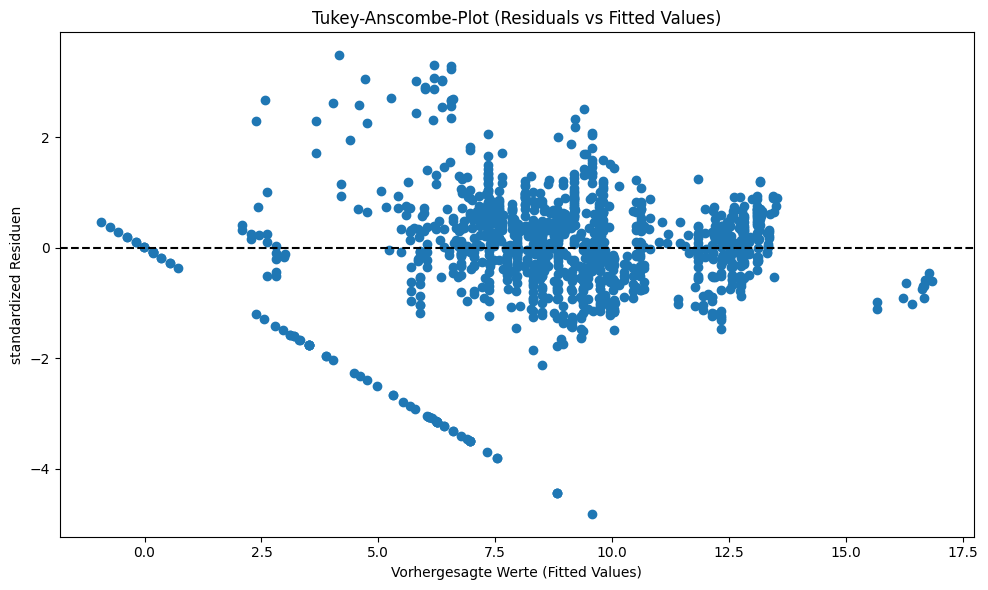

In [83]:
fitted_vals = ols_model.fittedvalues
standardized_residuals = ols_model.resid / ols_model.resid.std()

plt.figure(figsize=(10, 6))
plt.axhline(y=0, color='black', linestyle='--')
plt.scatter(fitted_vals, standardized_residuals)
plt.title('Tukey-Anscombe-Plot (Residuals vs Fitted Values)')
plt.xlabel('Vorhergesagte Werte (Fitted Values)')
plt.ylabel('standardized Residuen')
plt.tight_layout()
plt.show()

##### Interpretation des Tukey-Anscombe-Plots
Dieser Plot hilft, die Annahme der Homoskedastizität (konstante Varianz der Fehler/Residuen) und die Linearitätsannahme zu überprüfen. Idealerweise sollten die Punkte zufällig und gleichmäßig um die Nulllinie streuen, ohne erkennbares Muster.
Die mögliche Heteroskedastizität und die nicht perfekt zufällige Verteilung deuten darauf hin, dass das lineare Modell möglicherweise nicht alle systematischen Muster in den Daten erfasst. Die erkennbaren Muster könnten auf fehlende Prädiktoren oder nicht-lineare Zusammenhänge hindeuten. 